In [56]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [57]:
import os
import logging
import h5py
import matplotlib.pyplot as plt  # type: ignore
import numpy as np
import healpy as hp
from itertools import product

from mlpng.utils import (
    setup_logging,
    plot_cl_alm,
    plot_predictions,
    plot_histogram,
    plot_elsner_comp,
    save_data,
    remove_mono_dipole,
    # pol_str,
    make_alm_plots,
)
from mlpng.generator import Generator
from mlpng.utils.utils import print_errors

logger = setup_logging(__name__, level=logging.DEBUG)

mpi_comm = None

## Setup

In [58]:
generator = Generator(
    [
        "settings/n32.json",
        "--nsims",
        "100",
        "--narray",
        "1",
        # "--fnl_range",
        # "-1000",
        # "1000",
        "--pols",
        "T",
        "--shape",
        "local",
        # "--no-noise",
        # "--mc_steps",
        # "100",
        # "--nside",
        # "128",
        # "--lmax",
        # "383",
    ]
)

# check if we actually need to run / clean files
# generator.check_existing_data_file()

# generator.run()

26-Feb-25 16:54:10 - mlpng.core - DEBUG - Parsing CLI args: ['settings/n32.json', '--nsims', '100', '--narray', '1', '--pols', 'T', '--shape', 'local']
26-Feb-25 16:54:10 - mlpng.core - INFO - Loading settings from file 'settings/n32.json'
26-Feb-25 16:54:10 - mlpng.core - DEBUG - Forcing setting 'nsims' to 100 due to CLI
26-Feb-25 16:54:10 - mlpng.core - DEBUG - Forcing setting 'narray' to 1 due to CLI
26-Feb-25 16:54:10 - mlpng.core - DEBUG - Forcing setting 'pols' to ['T'] due to CLI
26-Feb-25 16:54:10 - mlpng.core - DEBUG - Forcing setting 'shapes' to ['local'] due to CLI
26-Feb-25 16:54:10 - mlpng.core - DEBUG - Overriding cosmo param 'As' from 2.13e-09 to 2.457e-09
26-Feb-25 16:54:10 - mlpng.core - DEBUG - Overriding cosmo param 'ns' from 0.9624 to 0.9649
26-Feb-25 16:54:10 - mlpng.core - DEBUG - Running with settings: 
{
  "cosmo_params": {
    "As": 2.457e-09,
    "ns": 0.9649,
    "pivot_scalar": 0.05,
    "H0": 67.4,
    "ombh2": 0.0224,
    "omch2": 0.12,
    "tau": 0.054
  

In [59]:
pol_idxs = generator.pol_idxs()

alm_l = generator.generate_alm()
alm_nl = generator.generate_alm_nl(alm_l)
# alm_nl = generator.generate_alm_nl_shape(alm_l)
fnls = generator.rng.uniform(
    generator.fnl_min, generator.fnl_max, (generator.total_sims, 1, 1)
)

# Add the duplicate dimension to the alms
alm_l = alm_l[:, pol_idxs]

# finally combine into the full alms and remove the monopole and dipole terms
alms = alm_l + fnls * alm_nl
print(alms[0, 0, :2])

26-Feb-25 16:54:11 - mlpng.utils.utils - DEBUG - Removing monopole and dipole from alms with lmax -1 and shape (100, 3, 4656)


26-Feb-25 16:54:16 - mlpng.generator - DEBUG - Using temp folder for alm_nl generation: /lustre/scratch/client/users/stevensonb
26-Feb-25 16:54:16 - mlpng.generator - DEBUG - Starting...


alm_nl:   0%|          | 0/100 [00:00<?, ?it/s]

[0.+0.j 0.+0.j]


In [60]:
# logger.info("Starting lensing")
# alm_lensed = generator.lens_alms(alms)

# maps_lensed = np.zeros(generator.map_shape, dtype=generator.r_dtype)
# for sim, dup in product(range(generator.nsims), range(generator.ndups)):
#     rmap = hp.alm2map(alm_lensed[sim], nside=generator.nside, pol=generator.use_pols)
#     maps_lensed[sim, dup] = hp.reorder(rmap, r2n=True)

## Alm

(100, 1, 4656) (100, 1, 4656) (100, 1, 4656)


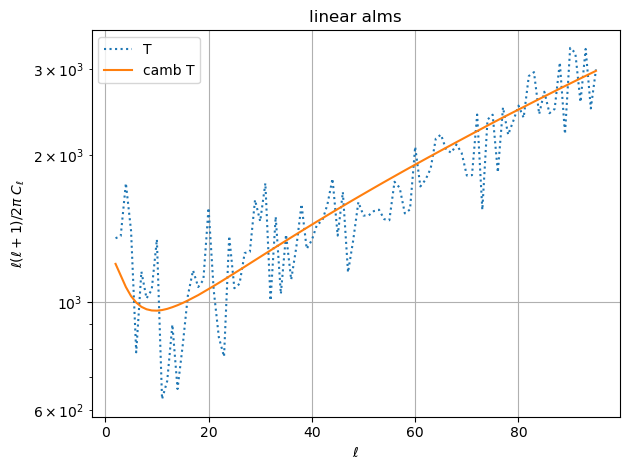

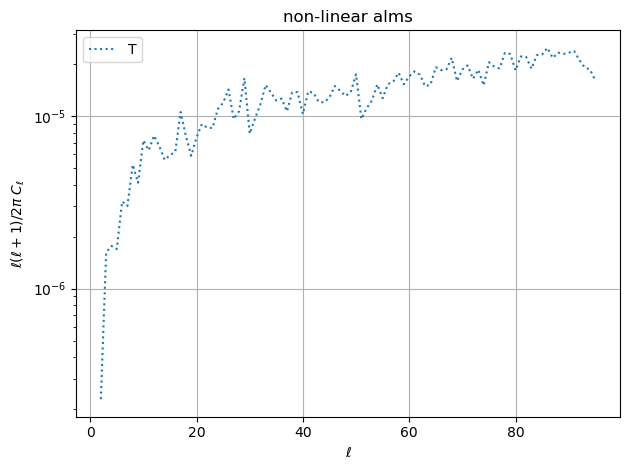

In [61]:
print(alm_l.shape, alm_nl.shape, alms.shape)
plot_cl_alm(
    generator,
    alm_l[0],
    title="linear alms",
    # labels=plt_labels,
    plot_camb=True,
    plot_noise=False,
    plot_full_camb=False,
    show=True,
)

ells = np.arange(generator.nell)
scale = (ells * (ells + 1)) / (2 * np.pi)

plot_cl_alm(
    generator,
    alm_nl[0],
    title="non-linear alms",
    plot_camb=False,
    plot_noise=False,
    plot_full_camb=False,
    show=True,
    scale=True,
)

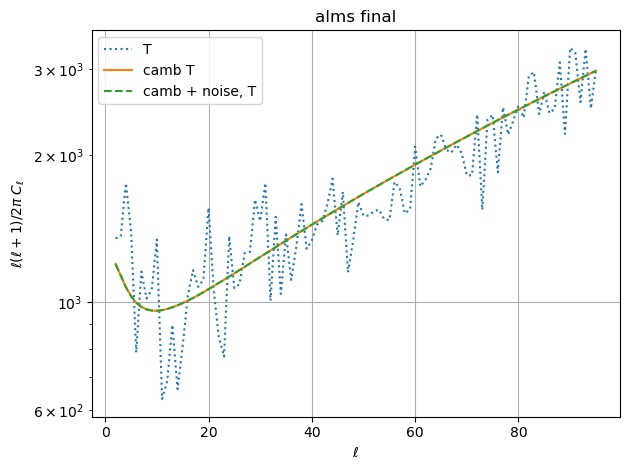

In [62]:
plot_cl_alm(
    generator,
    alms[0],
    title="alms final",
    plot_camb=True,
    plot_noise=False,
    plot_full_camb=True,
    show=True,
)

26-Feb-25 16:54:47 - mlpng.utils.plots - DEBUG - Mean ratio of alm T: 19818.707388166724
26-Feb-25 16:54:47 - mlpng.utils.plots - DEBUG - Mean ratio of elsner T: 14165.097310829738


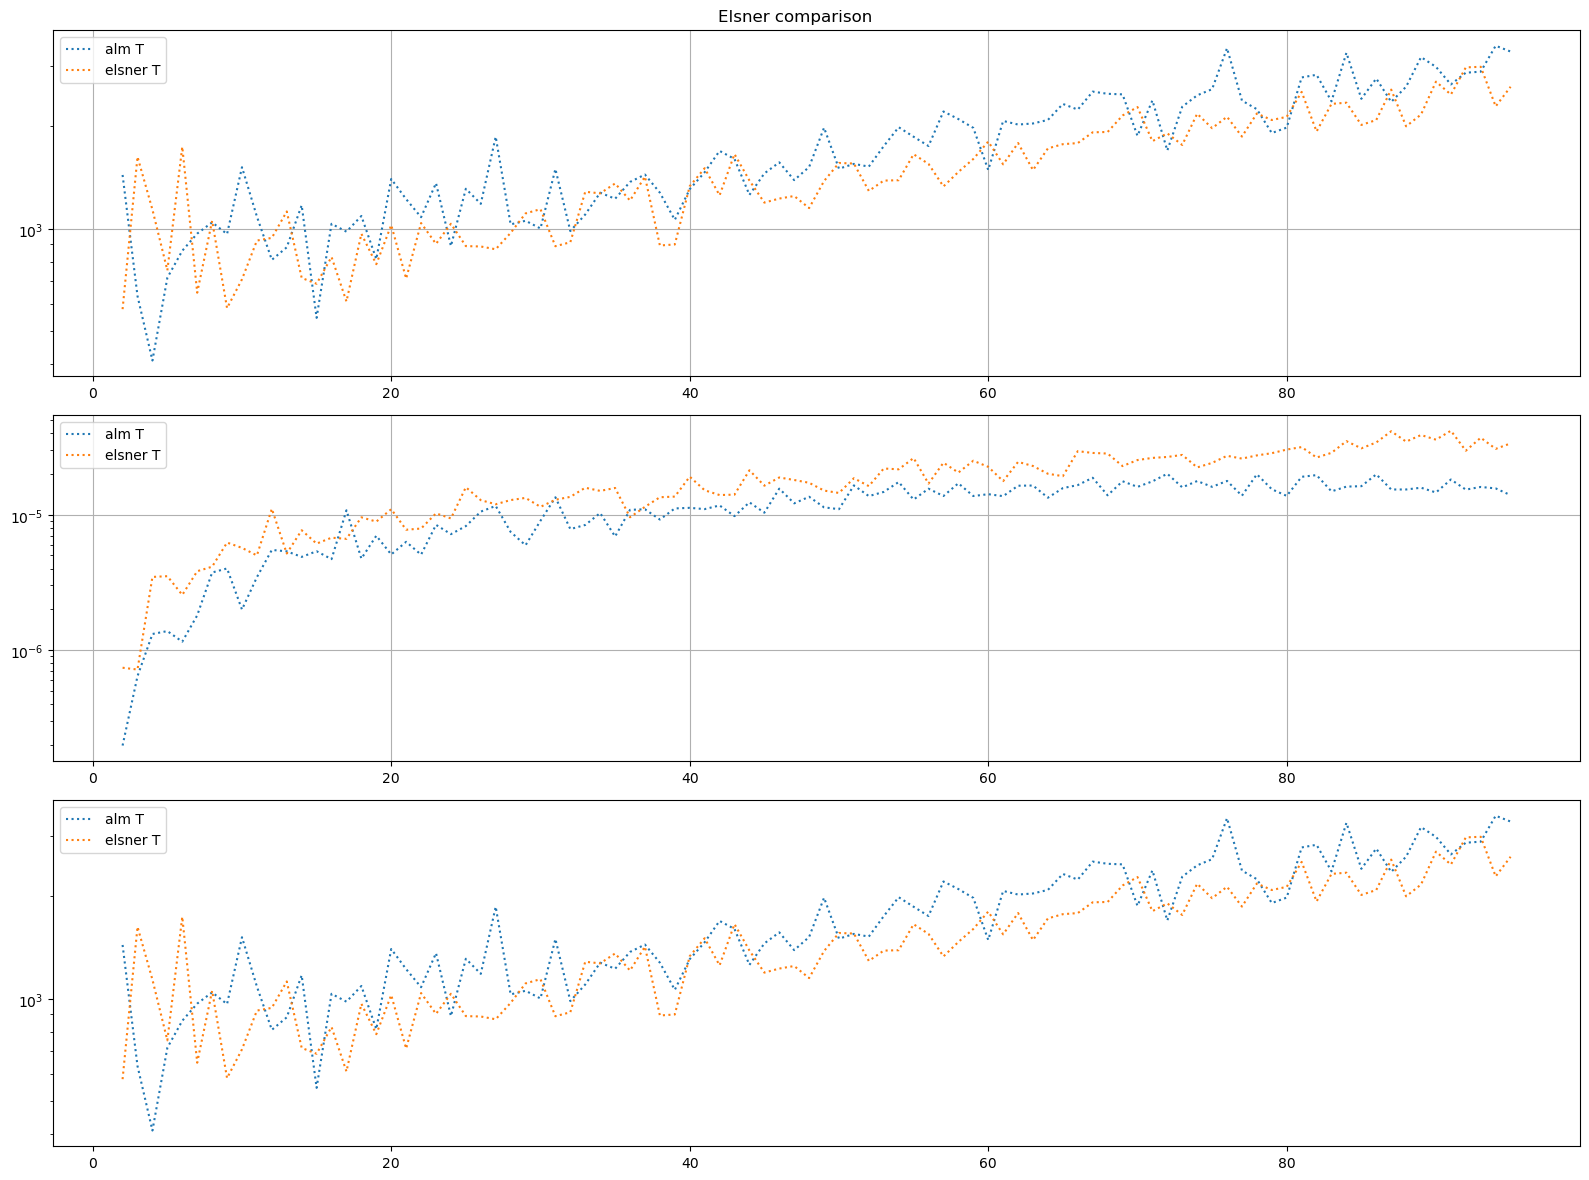

26-Feb-25 16:54:48 - mlpng.utils.plots - DEBUG - Mean ratio of alm T: 19818.707388166724
26-Feb-25 16:54:48 - mlpng.utils.plots - DEBUG - Mean ratio of elsner T: 14165.097310829738


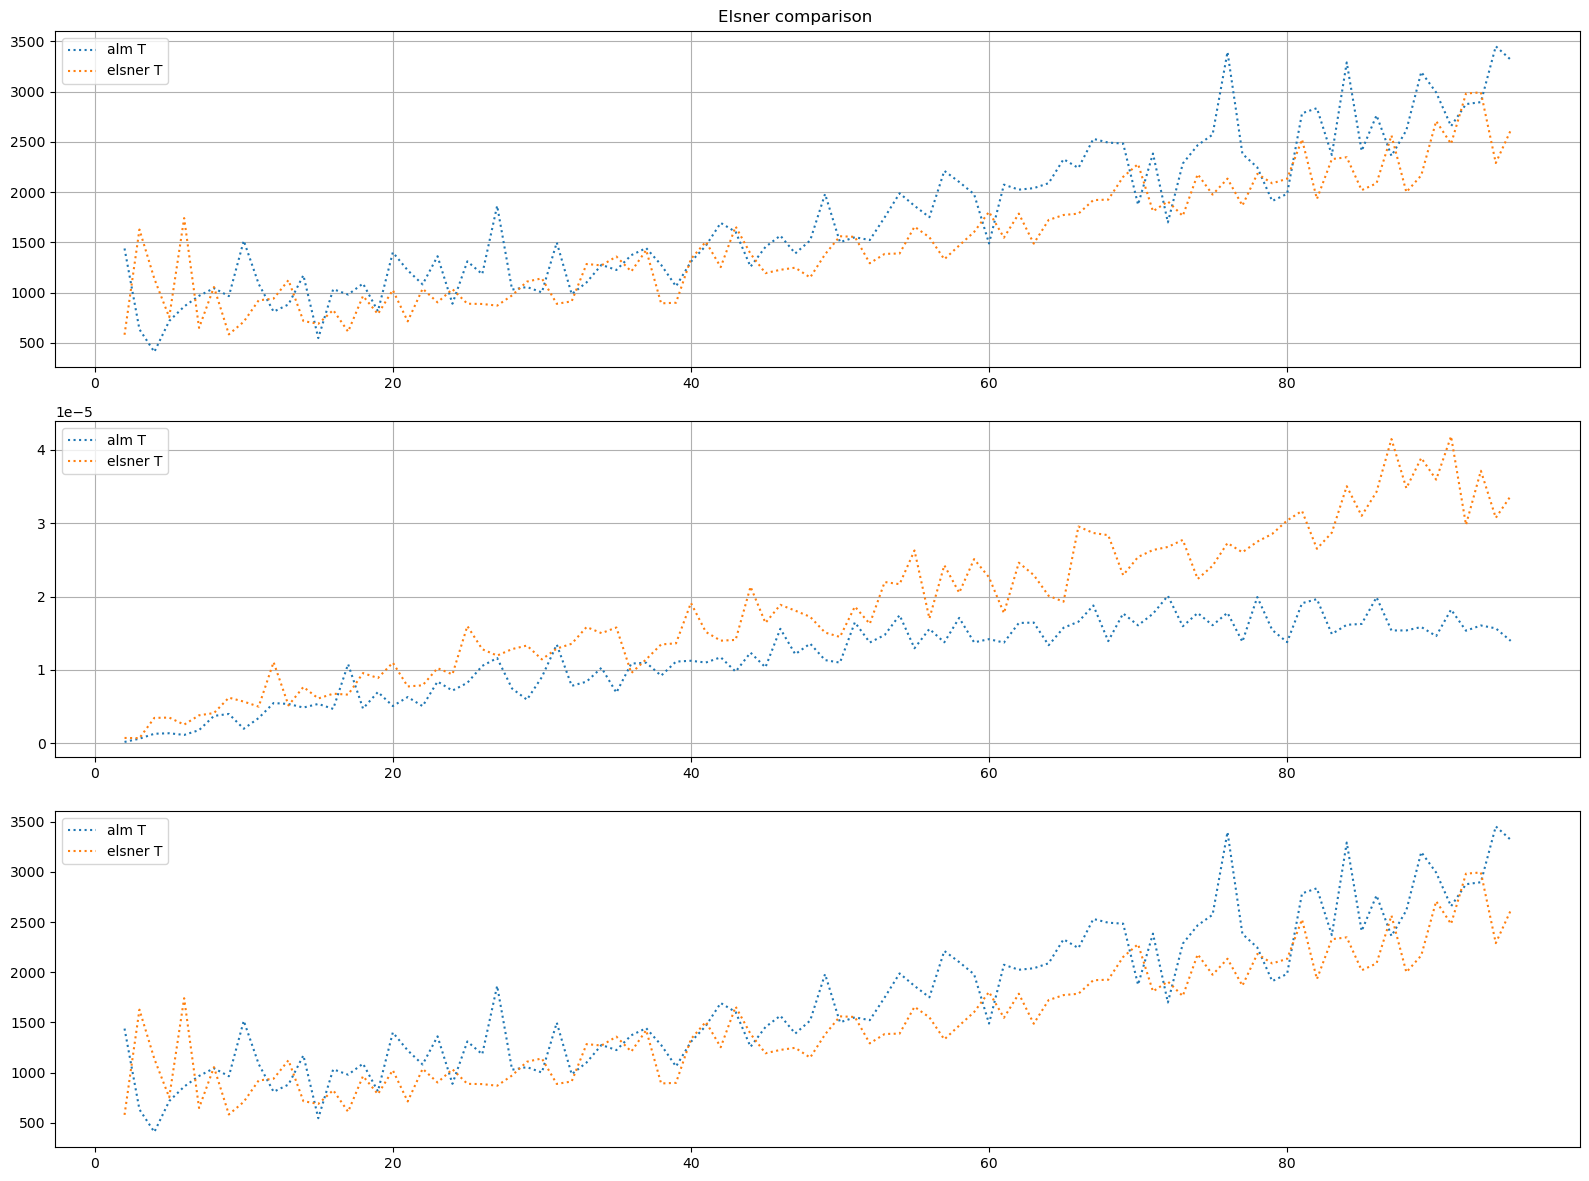

26-Feb-25 16:54:49 - mlpng.utils.plots - DEBUG - Mean ratio of alm T: 19818.707388166724
26-Feb-25 16:54:49 - mlpng.utils.plots - DEBUG - Mean ratio of elsner T: 14165.097310829738


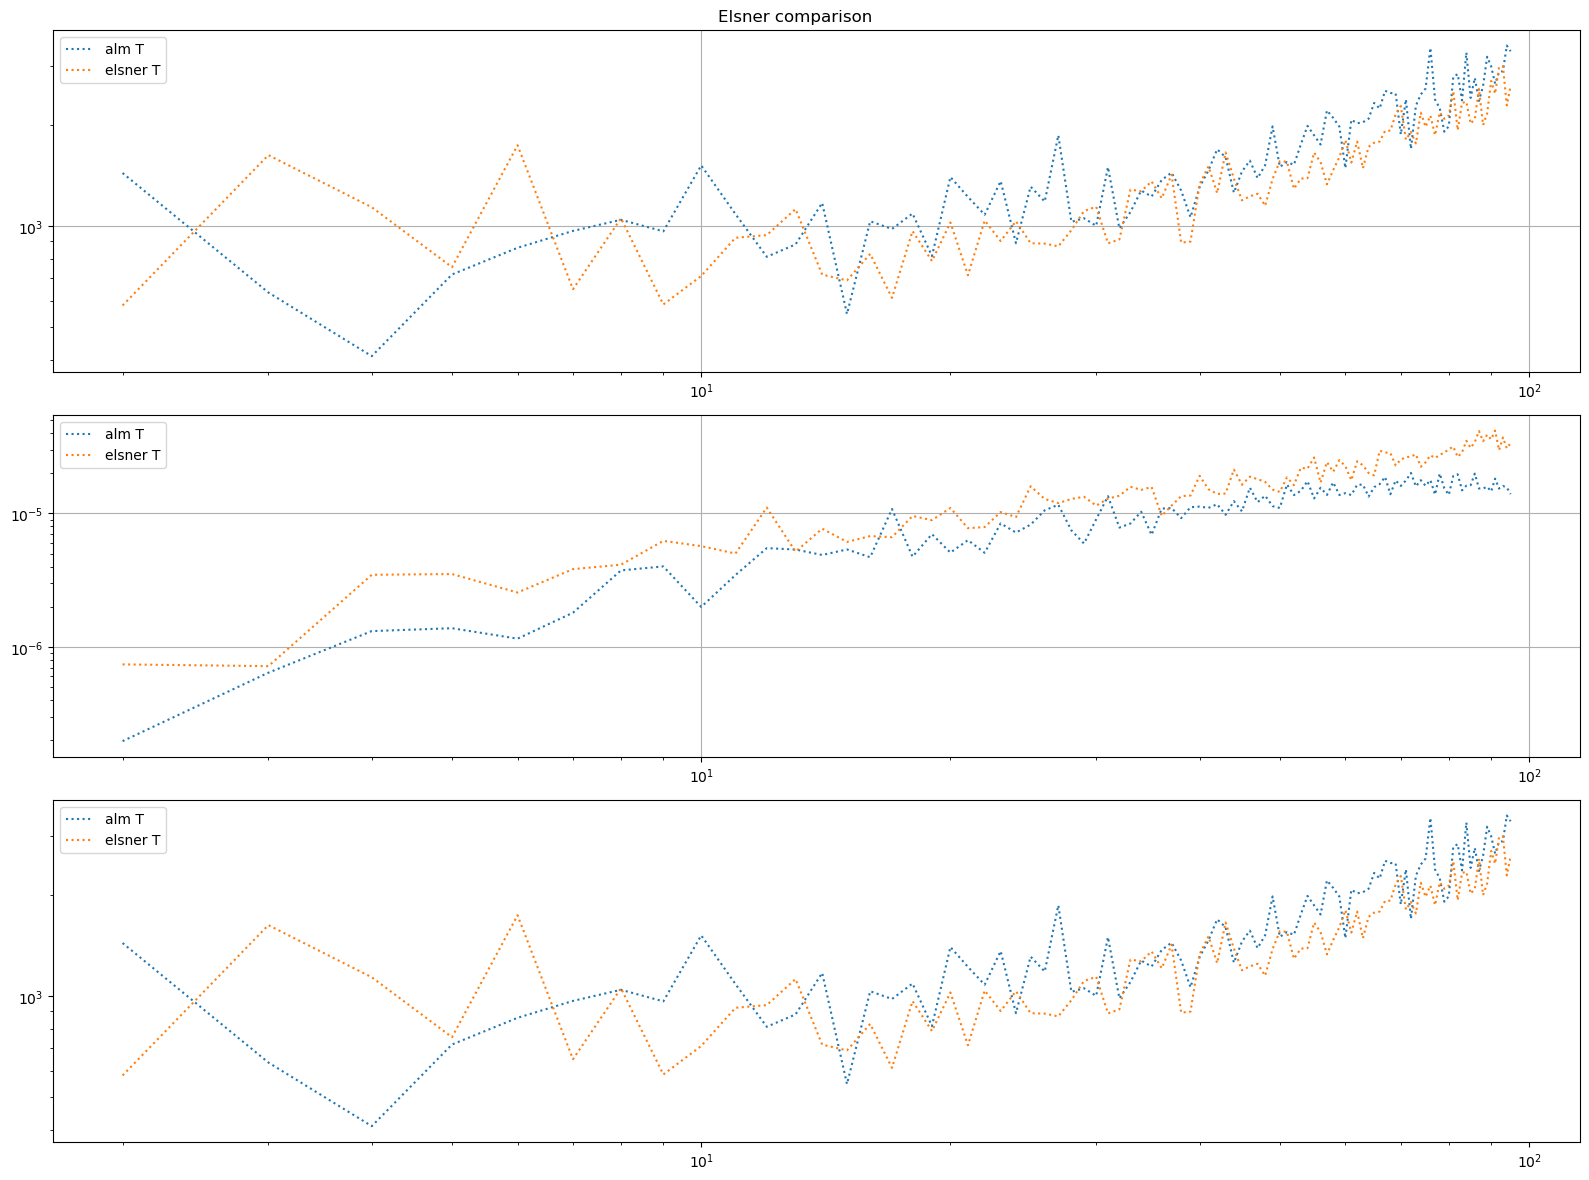

In [63]:
sim = generator.rng.integers(generator.nsims)
eidx = generator.rng.integers(1, 1001)
plot_elsner_comp(
    generator,
    alm_l[sim],
    alm_nl[sim],
    index=eidx,
    show=True,
    plot_func=plt.semilogy,
)
plot_elsner_comp(
    generator,
    alm_l[sim],
    alm_nl[sim],
    index=eidx,
    show=True,
    plot_func=plt.plot,
)
plot_elsner_comp(
    generator,
    alm_l[sim],
    alm_nl[sim],
    index=eidx,
    show=True,
    plot_func=plt.loglog,
)

26-Feb-25 16:54:50 - mlpng.utils.plots - DEBUG - Averaging 100 elsner sims, this will take a while


Averaging elsner sims:   0%|          | 0/100 [00:00<?, ?it/s]

26-Feb-25 16:55:01 - mlpng.utils.plots - DEBUG - Mean ratio of alm T: 18829.993915629406
26-Feb-25 16:55:01 - mlpng.utils.plots - DEBUG - Mean ratio of elsner T: 13780.669249457596


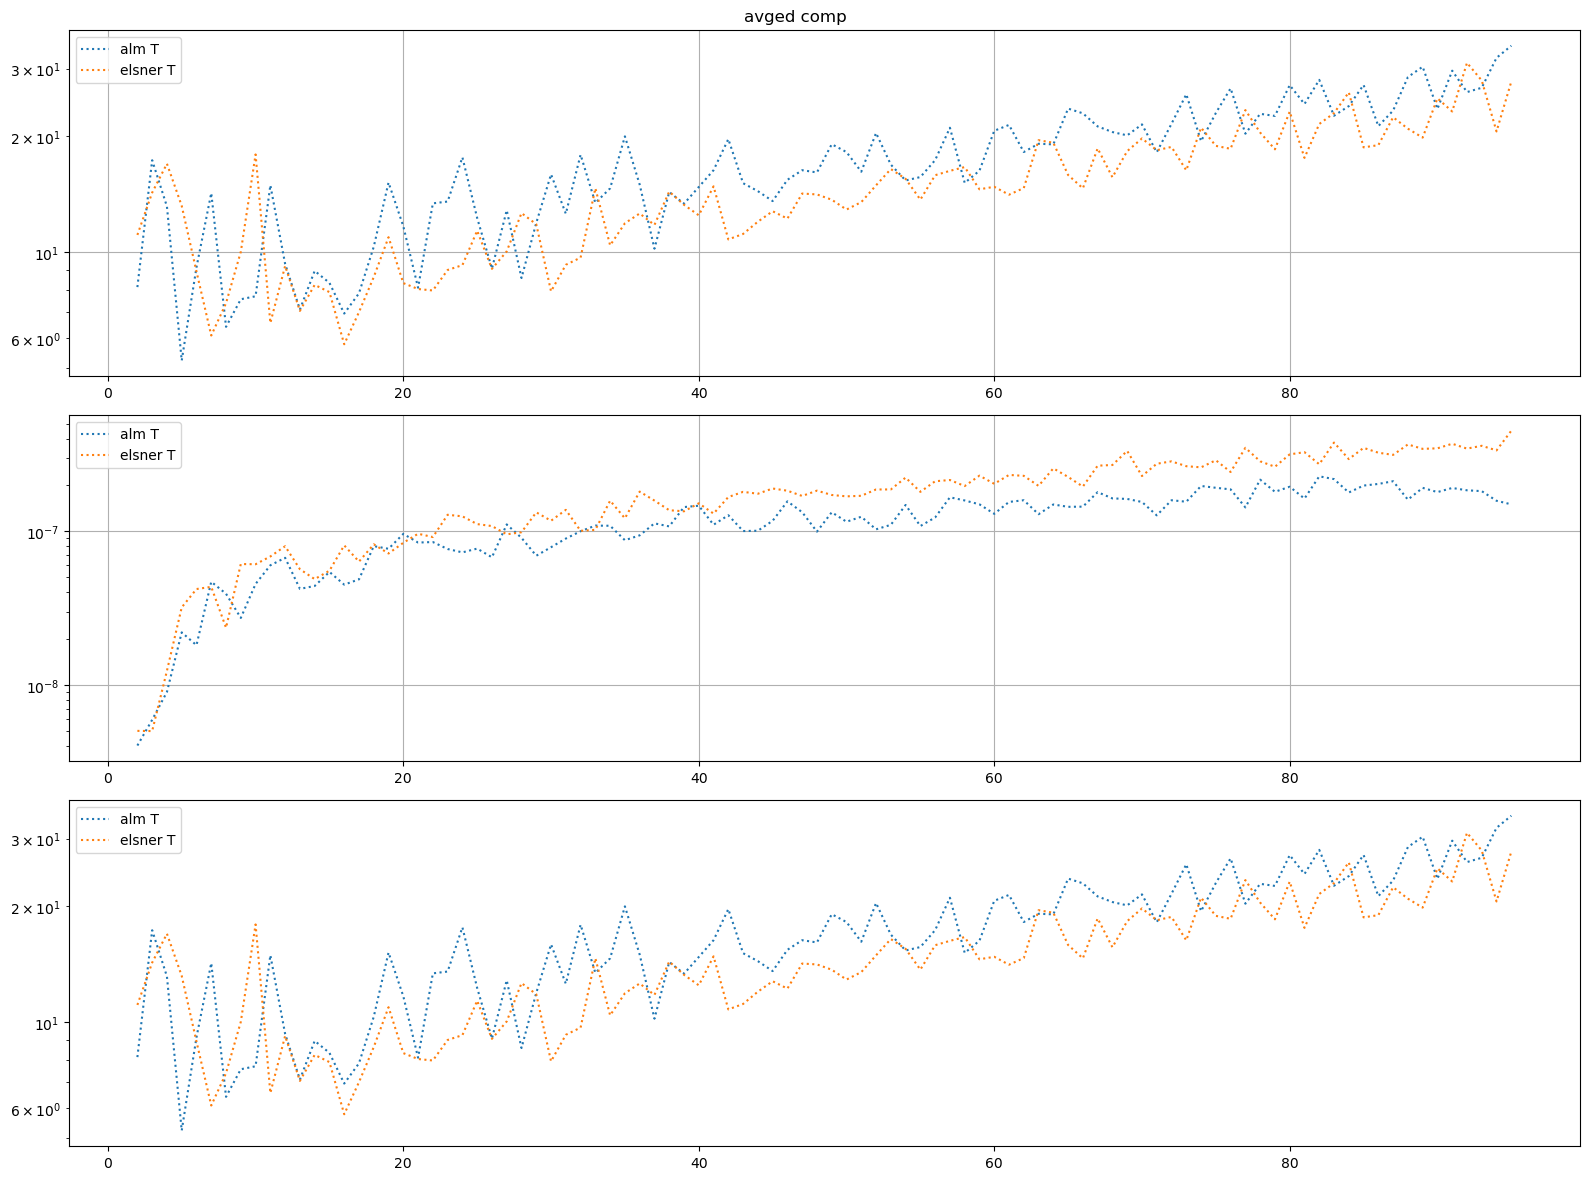

In [64]:
alm_l_avg = np.mean(alm_l, axis=0)
alm_ng_avg = np.mean(alm_nl, axis=0)

plot_elsner_comp(
    generator,
    alm_l_avg,
    alm_ng_avg,
    average=generator.nsims,
    title="avged comp",
    show=True,
    plot_func=plt.semilogy,
)

## Estimator

In [65]:
mpi_size = 1

# the KSW code requires the total_sims to be >= mpi_size
# best usage would have total_sims % mpi_size == 0, but not required
assert (
    generator.num_estimates >= mpi_size
), "total_sims < mpi_size, lower ntasks or increase sims"

logger.info(
    "Computing %s estimates in %.2f batches",
    generator.num_estimates,
    generator.num_estimates / mpi_size,
)
if generator.num_estimates % mpi_size != 0:
    logger.warning(
        "num_estimates is not divisible by mpi_size, "
        "this will lead to uneven workloads."
    )

# The default theta_batch size is 25, which is really small, we want to increase it
theta_batch = int(np.floor(1.5 * generator.lmax + 1)) // mpi_size
logger.debug("Using theta_batch %s", theta_batch)


# alm_steps = generator.generate_alm(nsims=generator.mc_steps)

logger.info("Initializing KSW with %s steps", generator.mc_steps)
ksw = generator.get_ksw("local")
fisher = ksw.compute_fisher()
print(f"Fisher: {fisher}, standard deviation: {1 / np.sqrt(fisher)}")

26-Feb-25 16:55:02 - __main__ - INFO - Computing 100 estimates in 100.00 batches
26-Feb-25 16:55:02 - __main__ - DEBUG - Using theta_batch 143
26-Feb-25 16:55:02 - __main__ - INFO - Initializing KSW with 300 steps


26-Feb-25 16:55:07 - mlpng.utils.utils - DEBUG - Removing monopole and dipole from alms with lmax 23 and shape (300, 3, 4656)
26-Feb-25 16:55:07 - mlpng.generator - DEBUG - Initalizing KSW with 300 steps
Fisher: 0.0001366619078674426, standard deviation: 85.54138158586922


26-Feb-25 16:55:57 - mlpng.utils.utils - INFO - Standard deviation from fisher: 85.54138158586922, SEM: 8.554138158586921
26-Feb-25 16:55:57 - mlpng.utils.utils - INFO - Mean error: -1.831556558787749, Median error: -3.322861453389663
26-Feb-25 16:55:57 - mlpng.utils.utils - INFO - 69.0% (62.0, 76.0) are within 1 standard deviations
26-Feb-25 16:55:57 - mlpng.utils.utils - INFO - 94.0% (92.0, 96.0) are within 2 standard deviations
26-Feb-25 16:55:57 - mlpng.utils.utils - INFO - 100.0% (98.0, 100.0) are within 3 standard deviations
26-Feb-25 16:55:57 - mlpng.utils.utils - INFO - 100.0% (100.0, 100.0) are within 4 standard deviations
26-Feb-25 16:55:57 - mlpng.utils.utils - INFO - 100.0% (100.0, 100.0) are within 5 standard deviations


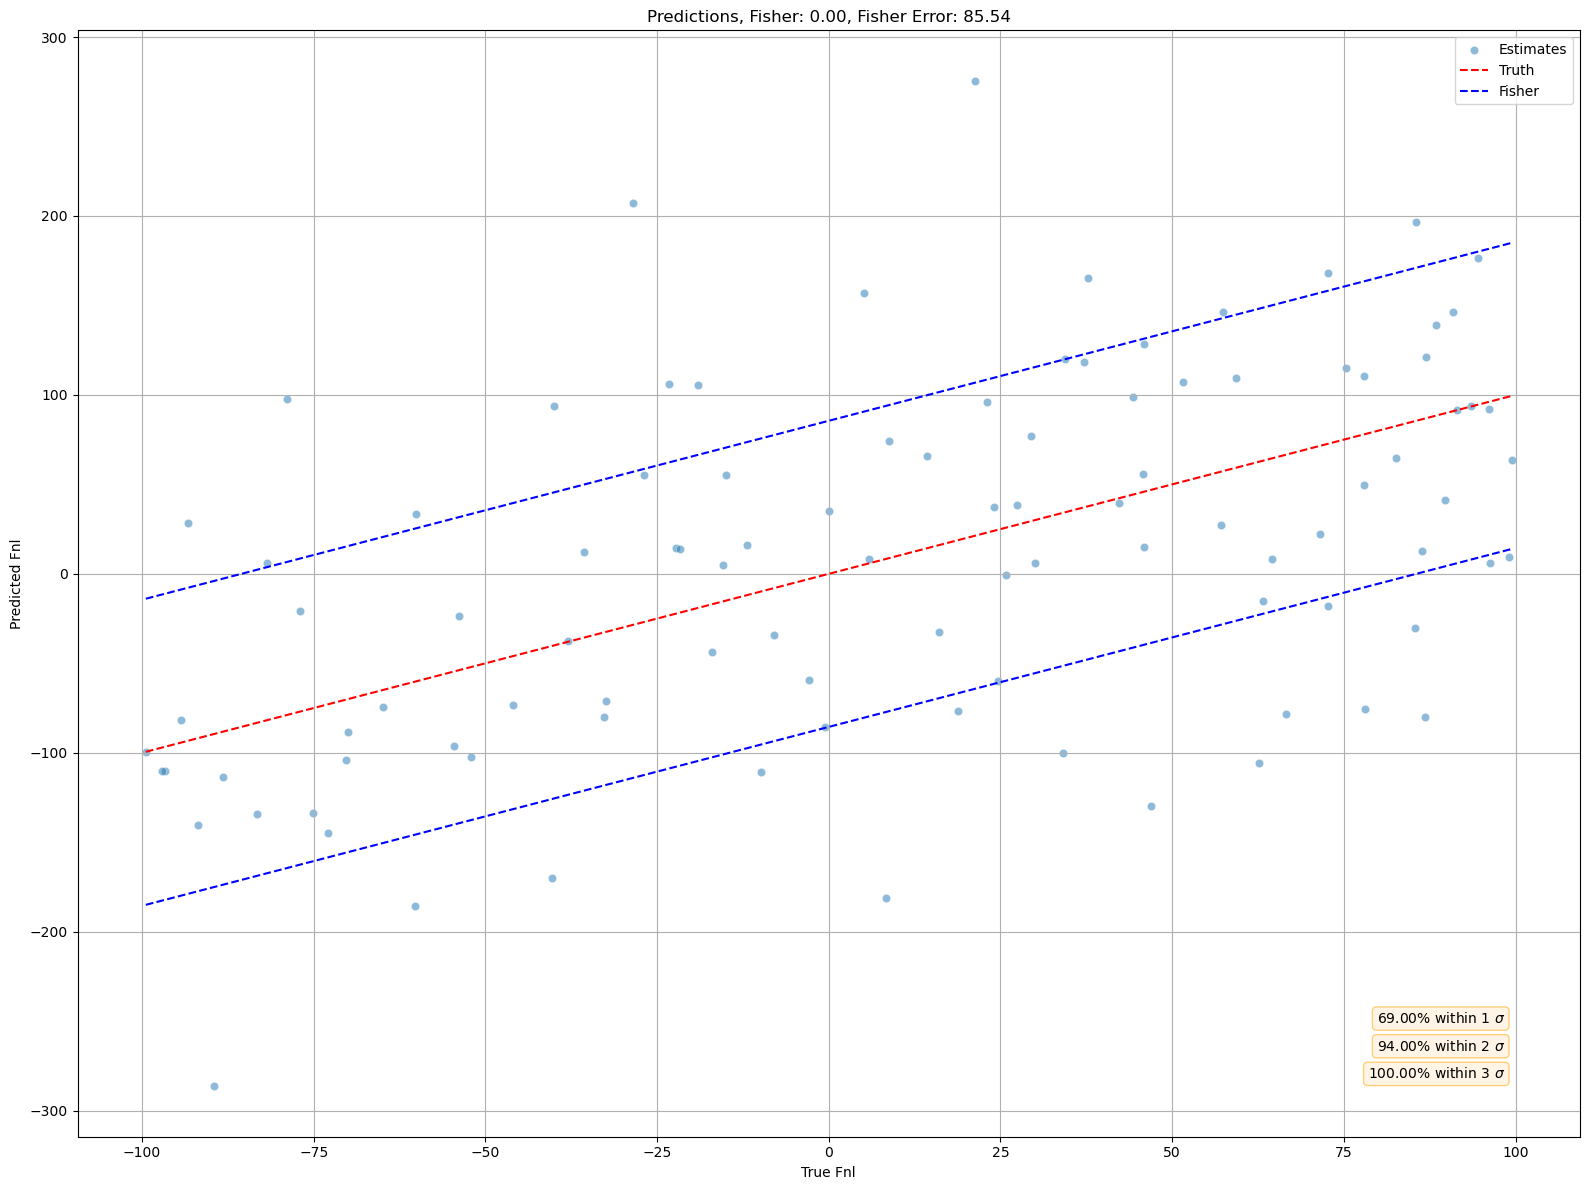

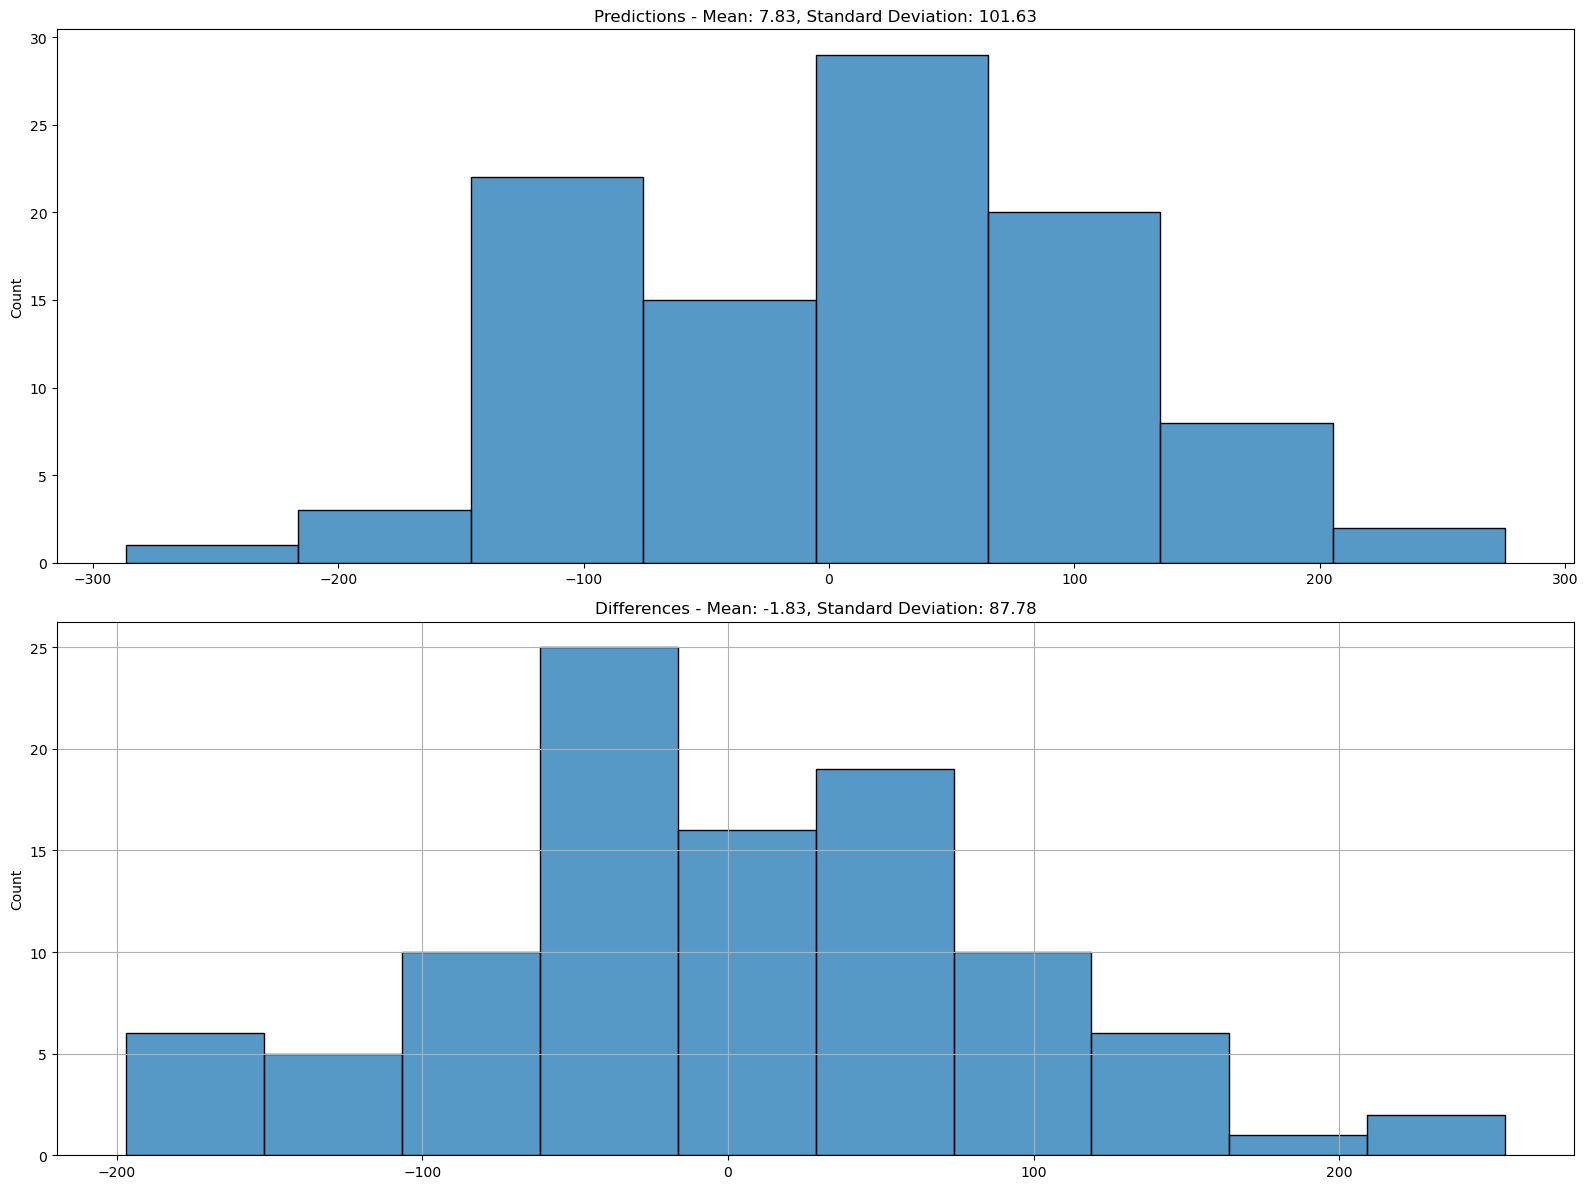

In [72]:
estimates, _, _, _ = ksw.compute_estimate_batch(
    lambda idx: generator.icov_func(alms[idx]),  # generator.icov),
    # lambda idx: alms[idx],
    range(generator.nsims),
    theta_batch=int(np.floor(1.5 * generator.lmax + 1)) // generator.slurm.n_cpus,
    fisher=fisher,
    # lin_term=0,
)

fnls_flat = fnls.flatten()
print_errors(fnls_flat, estimates, fisher)
plot_predictions(fnls_flat, estimates, fisher=fisher, show=True)
plot_histogram(fnls_flat, estimates, show=True)

## Lensing

In [67]:
# alm_lensed = generator.lens_alms(alms)

In [68]:
# sim = 0
# for i, pol in enumerate(generator.pol_idxs()):
#     pstr = generator.pols[pol]

#     ylabel = r"$\ell(\ell+1)/2\pi\;C_{\ell}" + f"^{pstr}$"
#     plot_cl_alm(
#         generator,
#         alm_lensed[sim, i],
#         # save_file=filebase,
#         ylabel=ylabel,
#         plot_camb=True,
#         plot_noise=False,
#         plot_full_camb=True,
#         show=True,
#         lmin=2,
#     )

In [69]:
# lens_estimates, _, _, _ = ksw.compute_estimate_batch(
#     lambda a: generator.icov_func(
#         alm_lensed[a, 0, generator.pol_idxs(pretrimmed=True)]
#     ),
#     range(generator.nsims),
#     theta_batch=int(np.floor(1.5 * generator.lmax + 1)) // generator.slurm.n_cpus,
#     fisher=fisher,
#     lin_term=0,
# )

In [70]:
# print(
#     "fnl shape", fnls.shape, "estimates shape", lens_estimates.shape, "fisher", fisher
# )
# fnls_flat = fnls[:, 0, 0]
# print_errors(fnls_flat, lens_estimates, fisher)
# plot_predictions(fnls_flat, lens_estimates, fisher=fisher, show=True)
# plot_histogram(fnls_flat, lens_estimates, show=True)